In [1]:
print("Hello")

Hello


🐍 Python for Network Engineers — Day 1: f-strings (formatted strings)
Part 1 — The concept & why it matters
An f-string is a string prefixed with f that lets you drop variables and expressions directly inside { } placeholders. Instead of clumsy concatenation with +, you write the value right where it belongs.
For a network engineer this is everyday gold: you build CLI commands, format log lines, label interfaces, and render IP/hostname output constantly. f-strings make that clean and readable — and you can even pad/align numbers (great for tidy tabular output of ports, VLANs, or interface counters).
Part 2 — Example code
hostname = "core-sw-01"
mgmt_ip = "10.0.0.5"
vlan = 20
# Build a config command on the fly
command = f"interface vlan {vlan}"
print(command)              # interface vlan 20
# Format a clean status line
print(f"{hostname} ({mgmt_ip}) -> VLAN {vlan} is UP")
# core-sw-01 (10.0.0.5) -> VLAN 20 is UP
# Alignment for tidy tables (<15 = left-pad to 15 chars)
interfaces = {"Gi0/1": "up", "Gi0/2": "down", "Te1/1": "up"}
for intf, state in interfaces.items():
    print(f"{intf:<10}{state:>6}")
# Gi0/1         up
# Gi0/2       down
# Te1/1         up
Part 3 — Practice question
You're given:
device = "edge-rtr-02"
interface = "Gi0/3"
speed_mbps = 1000
Write a single f-string that prints:
edge-rtr-02 | Gi0/3 | 1.0 Gbps
👉 Hint: convert Mbps to Gbps inside the placeholder (speed_mbps / 1000) and format it to one decimal place using {value:.1f}.
Reply with your answer here whenever you like — tomorrow we'll build on this! 🚀

In [3]:
hostname = "core-sw-01"
mgmpt_ip = "10.0.0.5"
vlan = 20

# Build a config command on the fly
command = f"interface vlan {vlan}"
print(command)

# Format a clean status line
print(f"{hostname} ({mgmpt_ip})")
# core-sw-01 (10.0.0.5) -> VLAN 20 is UP




interface vlan 20
core-sw-01 (10.0.0.5)


In [4]:
# Alignment for tidy tables (<15 = left-pad to 15 chars)
interfaces = {"Gi0/1": "up", "Gi0/2":"down", "Te1/1": "up"}
for intf, state in interfaces.items():
    print(f"{intf:<10}{state:>6}")

Gi0/1         up
Gi0/2       down
Te1/1         up


In [5]:
print(f"{'Interface':<10}{'Status':>6}")
print("-" * 16)
for intf, state in interfaces.items():
    print(f"{intf:<10}{state:>6}")

Interface Status
----------------
Gi0/1         up
Gi0/2       down
Te1/1         up


Let’s break your code **step by step** in a clean, practical way 👇

***

## ✅ 1. Your Code

```python
interfaces = {"Gi0/1": "up", "Gi0/2":"down", "Te1/1": "up"}

for intf, state in interfaces.items():
    print(f"{intf:<10}{state:>6}")
```

***

## ✅ 2. What the dictionary is

```python
interfaces = {"Gi0/1": "up", "Gi0/2":"down", "Te1/1": "up"}
```

* This is a dictionary
* Key = interface name
* Value = status

👉 Example:

* `"Gi0/1"` → `"up"`
* `"Gi0/2"` → `"down"`

***

## ✅ 3. Loop explanation

```python
for intf, state in interfaces.items():
```

* `.items()` gives **key + value pairs**
* Each iteration:
  * `intf` = key (interface name)
  * `state` = value (status)

👉 Iteration looks like:

* `("Gi0/1", "up")`
* `("Gi0/2", "down")`
* `("Te1/1", "up")`

***

## ✅ 4. Important part — f-string formatting

```python
print(f"{intf:<10}{state:>6}")
```

This is where your formatting magic happens.

### 🔹 Rule:

In f-strings:

```
{value:alignment width}
```

* `<` → left align
* `>` → right align
* Number → total width (including spaces) [\[geeksforgeeks.org\]](https://www.geeksforgeeks.org/python/string-alignment-in-python-f-string/)

***

## ✅ 5. `{intf:<10}` → LEFT ALIGN

* Reserve **10 characters**
* Put `intf` on the **left**
* Add spaces on the **right**

Example:

```
"Gi0/1" → "Gi0/1     "
```

👉 Because `"Gi0/1"` is 5 chars → 5 spaces added

***

## ✅ 6. `{state:>6}` → RIGHT ALIGN

* Reserve **6 characters**
* Put `state` on the **right**
* Add spaces on the **left**

Example:

```
"up" → "    up"
"down" → "  down"
```

***

## ✅ 7. Final Output

```
Gi0/1         up
Gi0/2       down
Te1/1         up
```

➡️ Everything is nicely aligned like a table  
➡️ This is very useful for:

* Network CLI outputs
* Logging
* Reports

***

## ✅ 8. Why this is important (networking context 🔥)

Since you work with network devices, this helps you:

* Print interface tables cleanly
* Format script outputs (like LACP, BGP summaries)
* Create CLI-style outputs

Example upgrade:

```python
print(f"{'Interface':<10}{'Status':>6}")
print("-" * 16)
for intf, state in interfaces.items():
    print(f"{intf:<10}{state:>6}")
```

***

## ✅ 9. Short summary

* `{intf:<10}` → left align, width 10
* `{state:>6}` → right align, width 6
* Used for **clean column formatting**

***

If you want, I can extend this into a **real network-style table (with VLAN, speed, errors)** — useful for your automation scripts.


In [6]:
interfaces = {
    "Gi0/1": {"status": "up", "speed": "1G", "errors": 0},
    "Gi0/2": {"status": "down", "speed": "1G", "errors": 5},
    "Te1/1": {"status": "up", "speed": "10G", "errors": 0}
}

print(f"{'Interface':<10}{'Status':<8}{'Speed':<8}{'Errors':>6}")
print("-" * 32)

for intf, data in interfaces.items():
    print(f"{intf:<10}{data['status']:<8}{data['speed']:<8}{data['errors']:>6}")

Interface Status  Speed   Errors
--------------------------------
Gi0/1     up      1G           0
Gi0/2     down    1G           5
Te1/1     up      10G          0


In [7]:
lags = {
    "Po1": {"members": 2, "state": "up", "protocol": "LACP"},
    "Po10": {"members": 4, "state": "down", "protocol": "LACP"},
    "Po20": {"members": 1, "state": "up", "protocol": "Static"}
}

print(f"{'LAG':<8}{'Members':<10}{'State':<8}{'Protocol':>10}")
print("-" * 36)

for lag, data in lags.items():
    print(f"{lag:<8}{data['members']:<10}{data['state']:<8}{data['protocol']:>10}")


LAG     Members   State     Protocol
------------------------------------
Po1     2         up            LACP
Po10    4         down          LACP
Po20    1         up          Static


In [8]:
vlans = {
    10: {"name": "Users", "status": "active"},
    20: {"name": "Servers", "status": "active"},
    30: {"name": "Guest", "status": "suspended"}
}

print(f"{'VLAN':<6}{'Name':<12}{'Status':>10}")
print("-" * 28)

for vlan, data in vlans.items():
    print(f"{vlan:<6}{data['name']:<12}{data['status']:>10}")

VLAN  Name            Status
----------------------------
10    Users           active
20    Servers         active
30    Guest        suspended


In [9]:
bgp_neighbors = {
    "10.0.0.1": {"asn": 65001, "state": "Established", "prefixes": 120},
    "10.0.0.2": {"asn": 65002, "state": "Idle", "prefixes": 0},
    "10.0.0.3": {"asn": 65003, "state": "Established", "prefixes": 98}
}

print(f"{'Neighbor':<15}{'ASN':<8}{'State':<15}{'Prefixes':>10}")
print("-" * 48)

for nbr, data in bgp_neighbors.items():
    print(f"{nbr:<15}{data['asn']:<8}{data['state']:<15}{data['prefixes']:>10}")

Neighbor       ASN     State            Prefixes
------------------------------------------------
10.0.0.1       65001   Established           120
10.0.0.2       65002   Idle                    0
10.0.0.3       65003   Established            98


In [12]:
print(f"{'Device':^20}{'Status':^10}")
print("-" * 30)

devices = {
    "ear02.str07": "UP",
    "owa01.str40": "DOWN"
}

for dev, status in devices.items():
    print(f"{dev:^20}{status:^10}")

       Device         Status  
------------------------------
    ear02.str07         UP    
    owa01.str40        DOWN   


In [11]:
devices = ["ear02.str07", "owa01", "core-router-1"]

max_len = max(len(d) for d in devices)

for d in devices:
    print(f"{d:<{max_len}}  ONLINE")


ear02.str07    ONLINE
owa01          ONLINE
core-router-1  ONLINE


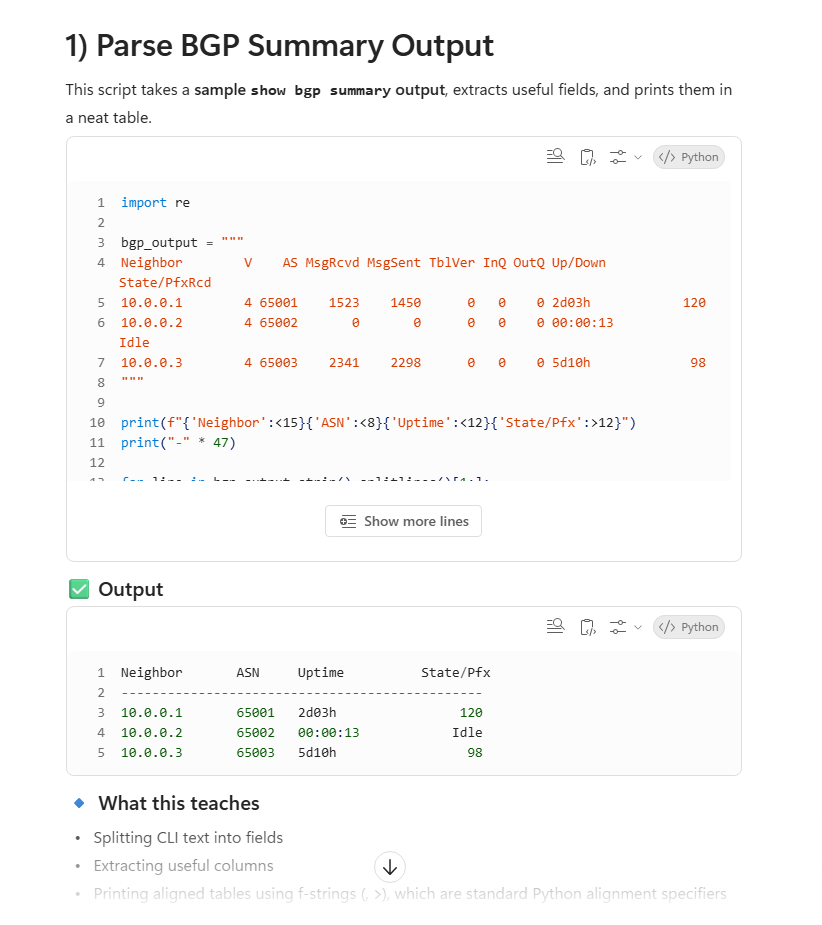

In [13]:
import re

bgp_output = """
Neighbor        V    AS MsgRcvd MsgSent TblVer InQ OutQ Up/Down  State/PfxRcd
10.0.0.1        4 65001    1523    1450      0   0    0 2d03h            120
10.0.0.2        4 65002       0       0      0   0    0 00:00:13         Idle
10.0.0.3        4 65003    2341    2298      0   0    0 5d10h             98
"""

print(f"{'Neighbor':<15}{'ASN':<8}{'Uptime':<12}{'State/Pfx':>12}")
print("-" * 47)

for line in bgp_output.strip().splitlines()[1:]:
    parts = line.split()
    neighbor = parts[0]
    asn = parts[2]
    uptime = parts[8]
    state_pfx = parts[9]
    print(f"{neighbor:<15}{asn:<8}{uptime:<12}{state_pfx:>12}")

Neighbor       ASN     Uptime         State/Pfx
-----------------------------------------------
10.0.0.1       65001   2d03h                120
10.0.0.2       65002   00:00:13            Idle
10.0.0.3       65003   5d10h                 98


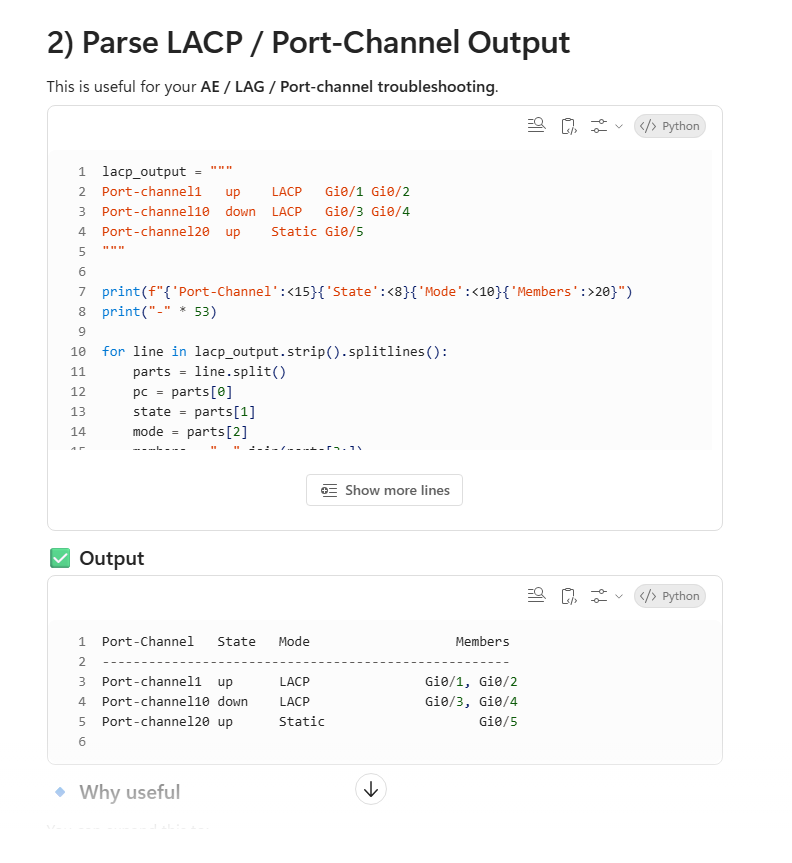

In [14]:
lacp_output = """
Port-channel1   up    LACP   Gi0/1 Gi0/2
Port-channel10  down  LACP   Gi0/3 Gi0/4
Port-channel20  up    Static Gi0/5
"""

print(f"{'Port-Channel':<15}{'State':<8}{'Mode':<10}{'Members':>20}")
print("-" * 53)

for line in lacp_output.strip().splitlines():
    parts = line.split()
    pc = parts[0]
    state = parts[1]
    mode = parts[2]
    members = ", ".join(parts[3:])
    print(f"{pc:<15}{state:<8}{mode:<10}{members:>20}")

Port-Channel   State   Mode                   Members
-----------------------------------------------------
Port-channel1  up      LACP              Gi0/1, Gi0/2
Port-channel10 down    LACP              Gi0/3, Gi0/4
Port-channel20 up      Static                   Gi0/5


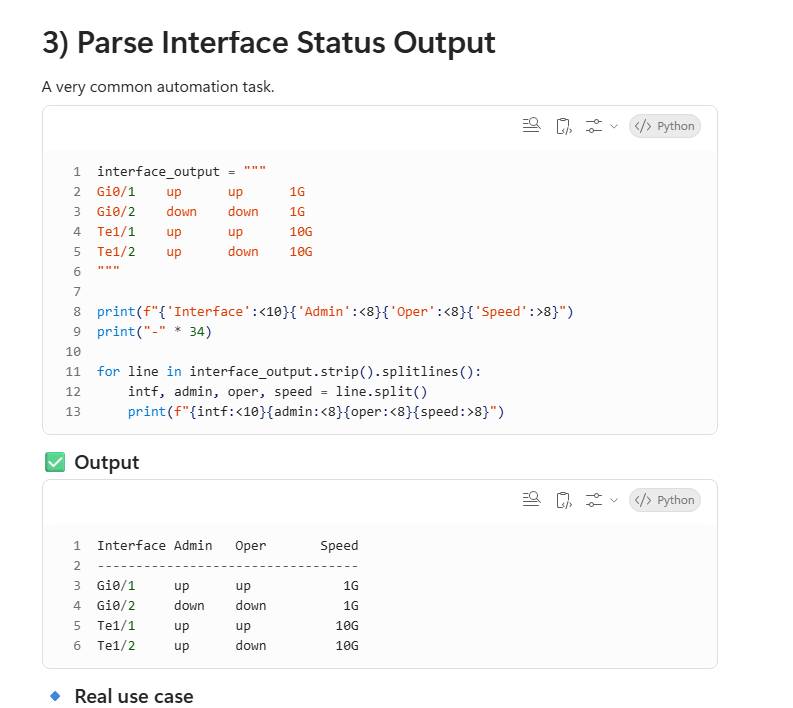

In [15]:
interface_output = """
Gi0/1    up      up      1G
Gi0/2    down    down    1G
Te1/1    up      up      10G
Te1/2    up      down    10G
"""

print(f"{'Interface':<10}{'Admin':<8}{'Oper':<8}{'Speed':>8}")
print("-" * 34)

for line in interface_output.strip().splitlines():
    intf, admin, oper, speed = line.split()
    print(f"{intf:<10}{admin:<8}{oper:<8}{speed:>8}")

Interface Admin   Oper       Speed
----------------------------------
Gi0/1     up      up            1G
Gi0/2     down    down          1G
Te1/1     up      up           10G
Te1/2     up      down         10G


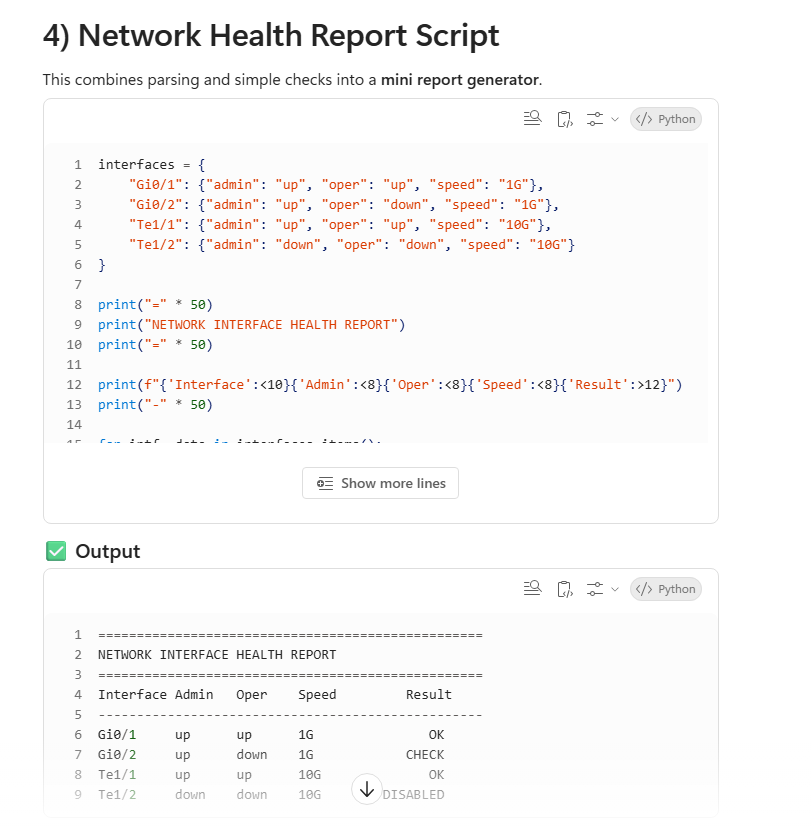

In [16]:
interfaces = {
    "Gi0/1": {"admin": "up", "oper": "up", "speed": "1G"},
    "Gi0/2": {"admin": "up", "oper": "down", "speed": "1G"},
    "Te1/1": {"admin": "up", "oper": "up", "speed": "10G"},
    "Te1/2": {"admin": "down", "oper": "down", "speed": "10G"}
}

print("=" * 50)
print("NETWORK INTERFACE HEALTH REPORT")
print("=" * 50)

print(f"{'Interface':<10}{'Admin':<8}{'Oper':<8}{'Speed':<8}{'Result':>12}")
print("-" * 50)

for intf, data in interfaces.items():
    admin = data["admin"]
    oper = data["oper"]
    speed = data["speed"]

    if admin == "up" and oper == "up":
        result = "OK"
    elif admin == "up" and oper == "down":
        result = "CHECK"
    else:
        result = "DISABLED"

    print(f"{intf:<10}{admin:<8}{oper:<8}{speed:<8}{result:>12}")


NETWORK INTERFACE HEALTH REPORT
Interface Admin   Oper    Speed         Result
--------------------------------------------------
Gi0/1     up      up      1G                OK
Gi0/2     up      down    1G             CHECK
Te1/1     up      up      10G               OK
Te1/2     down    down    10G         DISABLED


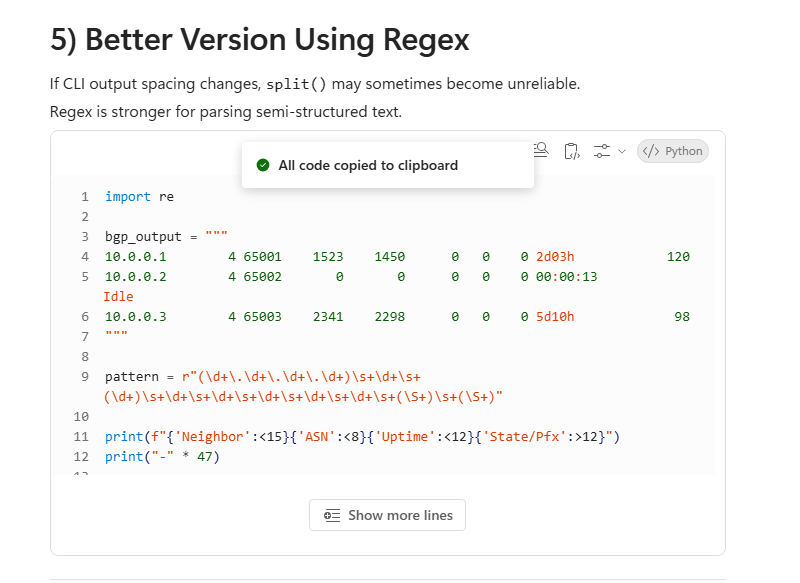

In [17]:
import re

bgp_output = """
10.0.0.1        4 65001    1523    1450      0   0    0 2d03h            120
10.0.0.2        4 65002       0       0      0   0    0 00:00:13         Idle
10.0.0.3        4 65003    2341    2298      0   0    0 5d10h             98
"""

pattern = r"(\d+\.\d+\.\d+\.\d+)\s+\d+\s+(\d+)\s+\d+\s+\d+\s+\d+\s+\d+\s+\d+\s+(\S+)\s+(\S+)"

print(f"{'Neighbor':<15}{'ASN':<8}{'Uptime':<12}{'State/Pfx':>12}")
print("-" * 47)

for match in re.finditer(pattern, bgp_output):
    neighbor = match.group(1)
    asn = match.group(2)
    uptime = match.group(3)
    state_pfx = match.group(4)
    print(f"{neighbor:<15}{asn:<8}{uptime:<12}{state_pfx:>12}")

Neighbor       ASN     Uptime         State/Pfx
-----------------------------------------------
10.0.0.1       65001   2d03h                120
10.0.0.2       65002   00:00:13            Idle
10.0.0.3       65003   5d10h                 98


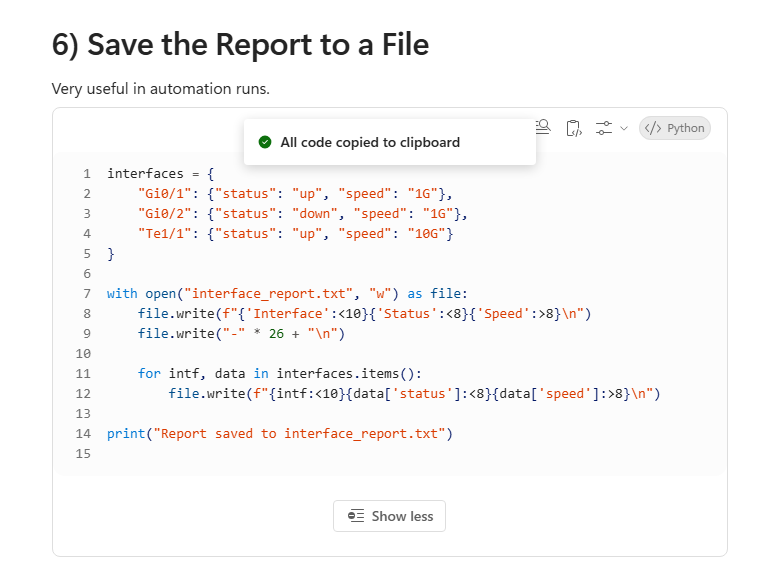

In [18]:
interfaces = {
    "Gi0/1": {"status": "up", "speed": "1G"},
    "Gi0/2": {"status": "down", "speed": "1G"},
    "Te1/1": {"status": "up", "speed": "10G"}
}

with open("interface_report.txt", "w") as file:
    file.write(f"{'Interface':<10}{'Status':<8}{'Speed':>8}\n")
    file.write("-" * 26 + "\n")

    for intf, data in interfaces.items():
        file.write(f"{intf:<10}{data['status']:<8}{data['speed']:>8}\n")

print("Report saved to interface_report.txt")


Report saved to interface_report.txt


In [19]:
interfaces = {
    "Gi0/1": {"admin": "up", "oper": "up", "speed": "1G"},
    "Gi0/2": {"admin": "up", "oper": "down", "speed": "1G"},
    "Te1/1": {"admin": "up", "oper": "up", "speed": "10G"},
    "Te1/2": {"admin": "down", "oper": "down", "speed": "10G"}
}

print(f"{'Interface':<10}{'Admin':<8}{'Oper':<8}{'Speed':<8}{'Remark':>10}")
print("-" * 44)

for intf, data in interfaces.items():
    if data["admin"] == "up" and data["oper"] == "down":
        remark = "ALERT"
    elif data["admin"] == "up" and data["oper"] == "up":
        remark = "OK"
    else:
        remark = "OFF"

    print(f"{intf:<10}{data['admin']:<8}{data['oper']:<8}{data['speed']:<8}{remark:>10}")

Interface Admin   Oper    Speed       Remark
--------------------------------------------
Gi0/1     up      up      1G              OK
Gi0/2     up      down    1G           ALERT
Te1/1     up      up      10G             OK
Te1/2     down    down    10G            OFF


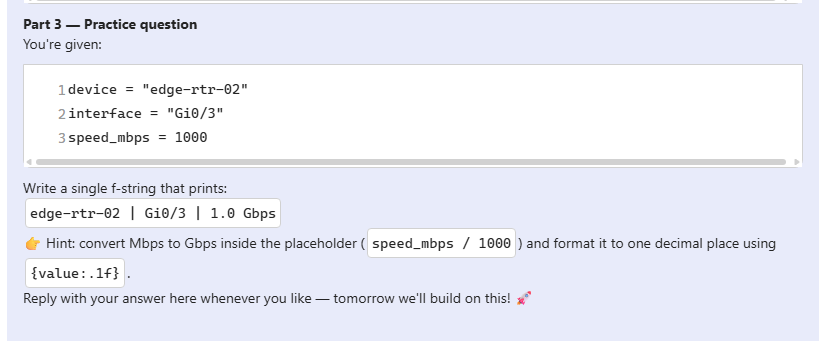

In [23]:
device = "edge-rtr-02"
interface = "Gi0/3"
speed_mbps = 1000

print(f"{device} | {interface} | {speed_mbps / 1000:.1f} Gbps")

edge-rtr-02 | Gi0/3 | 1.0 Gbps


🐍 Python for Network Engineers — Day 2: Lists & for loops


Part 1 — The concept & why it matters


A list is an ordered, changeable collection of items written in square brackets: ["sw1", "sw2", "sw3"]. A for loop lets you walk through that collection one item at a time and do the same work on each.


Why this matters for network engineering: almost everything you automate is "do X to every device / interface / VLAN / IP." Instead of copy-pasting a command 50 times, you store the 50 devices in a list and loop once. This is the foundation of every config-push, audit, and health-check script you'll ever write.


Handy basics:


devices[0] → first item (Python counts from 0)
devices.append("sw4") → add an item
len(devices) → how many items
for d in devices: → loop over each one
Part 2 — Example code
# A list of switches we manage
devices = ["core-sw1", "core-sw2", "access-sw1", "access-sw2"]
# Loop over each device and build a command
for device in devices:
    print(f"Connecting to {device}...")
    print(f"  Running: show version on {device}")
# Add a newly racked switch
devices.append("access-sw3")
print(f"\nWe now manage {len(devices)} devices.")
# enumerate() gives you a counter + the item — great for numbered output
for index, device in enumerate(devices, start=1):
    print(f"{index}. {device}")

Sample output:
Connecting to core-sw1...
  Running: show version on core-sw1
Connecting to core-sw2...
  Running: show version on core-sw2
... (and so on)
We now manage 5 devices.
1. core-sw1
2. core-sw2
3. access-sw1
4. access-sw2
5. access-sw3

Part 3 — Practice question 📝
You have this list of management IPs:
mgmt_ips = ["10.0.0.1", "10.0.0.2", "10.0.0.3"]

Write a for loop that prints, for each IP, the line: Pinging 10.0.0.1 (using an f-string from Day 1!). Bonus: after the loop, append "10.0.0.4" to the list and print how many IPs are now in it.
Reply with your answer and I'll check it. Happy coding! 🚀
— Microsoft Internal Python Notes

In [24]:
# A list of switches we manage
devices = ["core-sw1", "core-sw2", "access-sw1", "access-sw2"]

# Loop over each device and build a command
for device in devices:
    print(f"Connecting to {device} .......")
    print(f"Running: Show version on {device}")

Connecting to core-sw1 .......
Running: Show version on core-sw1
Connecting to core-sw2 .......
Running: Show version on core-sw2
Connecting to access-sw1 .......
Running: Show version on access-sw1
Connecting to access-sw2 .......
Running: Show version on access-sw2


In [26]:
#add a newly racked switch. 
devices.append("access-sw3")
print(devices)
print(f"\n We now manage {len(devices)} devices. ")

['core-sw1', 'core-sw2', 'access-sw1', 'access-sw2', 'access-sw3', 'access-sw3']

 We now manage 6 devices. 


In [28]:
#enumerate () gives you a counter + the item - great for numbered output. 

for index, device in enumerate(devices, start=1):
    print(f"{index}. {device}")

1. core-sw1
2. core-sw2
3. access-sw1
4. access-sw2
5. access-sw3
6. access-sw3
7. access-sw3


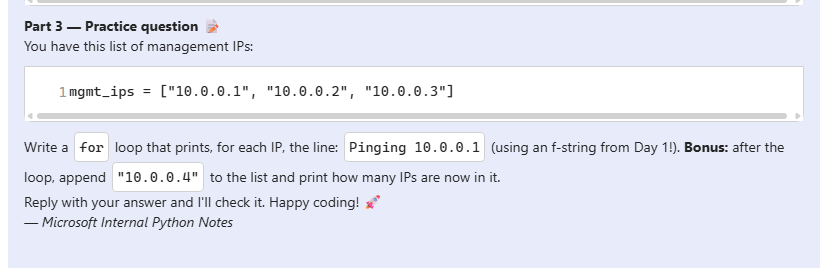

In [29]:
mgmt_ips = ["10.0.0.1", "10.0.0.2", "10.0.0.3"]

for mgmt in mgmt_ips:
    print(mgmt)

10.0.0.1
10.0.0.2
10.0.0.3


In [30]:
mgmt_ips.append("10.0.0.4")
print(mgmt_ips)
print(f"\n we now see all the {len(mgmt_ips)} mgmpt_ip address")

['10.0.0.1', '10.0.0.2', '10.0.0.3', '10.0.0.4']

 we now see all the 4 mgmpt_ip address


🐍 Python for Network Engineers — Day 3: Dictionaries
Part 1 — The concept & why it matters
A dictionary is a collection of key → value pairs, written in curly braces: {"sw1": "10.0.0.1"}. Unlike a list (which you access by position), you access a dictionary by its key — a meaningful name you choose.
This is the data structure for network work, because so much of our world is a mapping: hostname → IP, interface → status, VLAN ID → name, device → vendor. Instead of remembering "the IP is at index 3," you just ask for it by name: devices["sw1"]. Dictionaries are fast to look up, easy to read, and they're exactly the shape of JSON returned by network APIs (RESTCONF, Meraki, NetBox, etc.).
Part 2 — Example code snippets
Creating and reading a dictionary (device → IP):
devices = {
    "sw1": "10.0.0.1",
    "sw2": "10.0.0.2",
    "rtr1": "10.0.0.254",
}
print(devices["sw1"])        # 10.0.0.1
print(len(devices))          # 3  (number of devices)

Adding, updating, and safely reading with .get():
devices["fw1"] = "10.0.0.10"     # add a new entry
devices["sw1"] = "10.0.0.5"      # update an existing one
# .get() avoids a crash if the key is missing — returns a default instead
print(devices.get("sw9", "NOT FOUND"))   # NOT FOUND

Looping over a dictionary — the everyday pattern:
for hostname, ip in devices.items():
    print(f"{hostname} -> {ip}")
# sw1 -> 10.0.0.5
# sw2 -> 10.0.0.2
# rtr1 -> 10.0.0.254
# fw1 -> 10.0.0.10

Nested dictionary — richer data per device:
inventory = {
    "sw1": {"ip": "10.0.0.1", "vendor": "Arista", "model": "7050"},
    "rtr1": {"ip": "10.0.0.254", "vendor": "Cisco", "model": "ISR4451"},
}
print(inventory["rtr1"]["vendor"])   # Cisco

Part 3 — Practice question
You're given this dictionary of interfaces and their status:
interfaces = {
    "Gi0/1": "up",
    "Gi0/2": "down",
    "Gi0/3": "up",
    "Gi0/4": "down",
}

👉 Write a loop that prints only the interface names that are "down". Bonus: count how many are down and print the total.
(Hint: loop with .items() and use an if to check the status.)
Happy coding! 🚀
— Microsoft Internal Python Notes

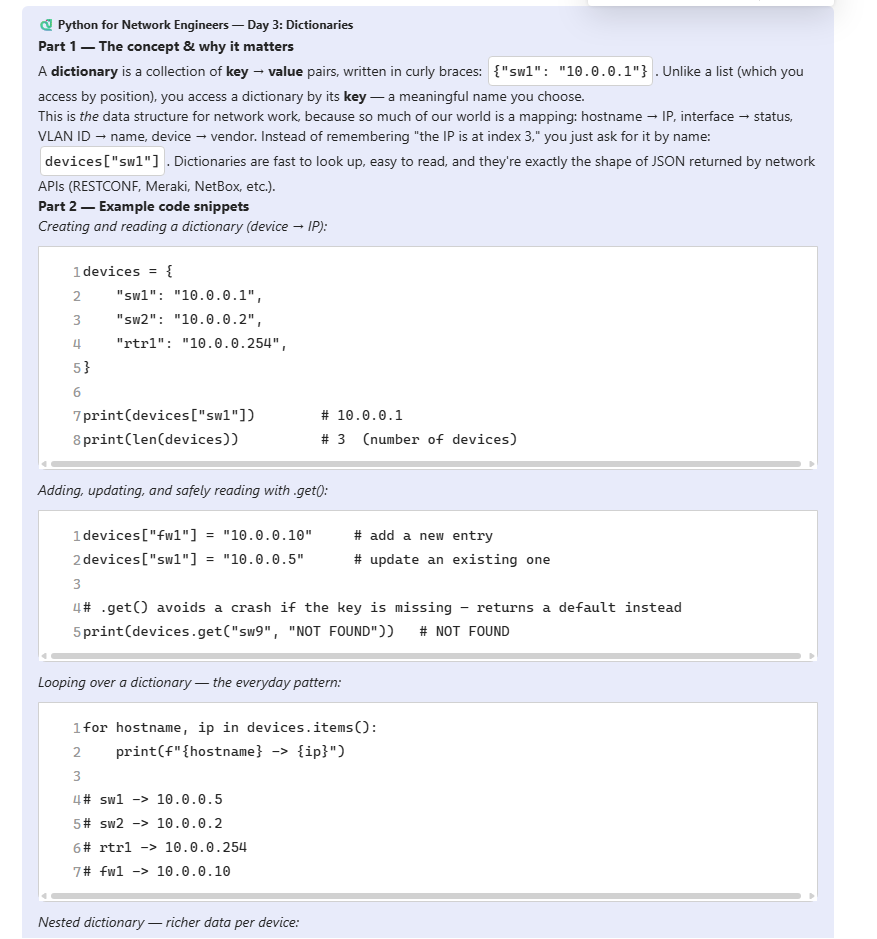

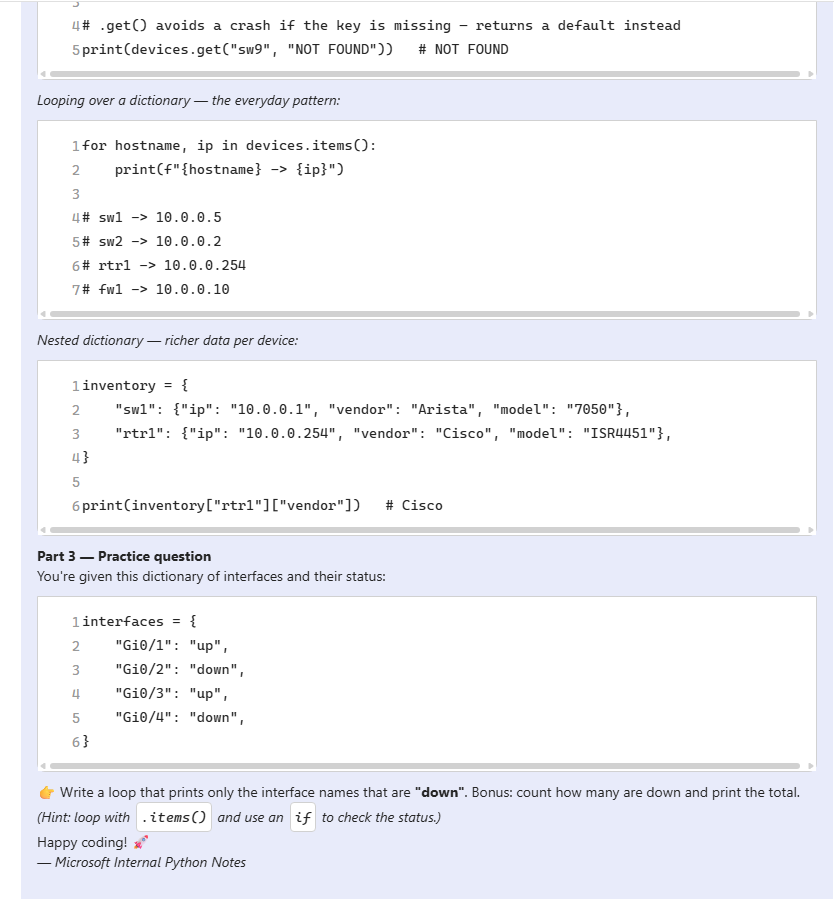

In [31]:
devices = {
    "sw1" : "10.0.0.1",
    "sw2" : "10.0.0.2",
    "rtr1" : "10.0.0.254"
}

print(devices["sw1"])
print(len(devices))

10.0.0.1
3


In [35]:
print(devices["sw2"])
print(devices["sw3"])

10.0.0.2


KeyError: 'sw3'

In [33]:
print("sw2")

sw2


In [36]:
print(devices["sw2"])
print(devices["rtr1"])

10.0.0.2
10.0.0.254


Adding, updating, and safely reading with .get():

In [38]:
devices["fw1"] = "10.0.0.10"      # add a new entry
devices["sw1"] = "10.0.0.5"          # update an existing one


# .get() avoids a crash if the key is missing — returns a default instead
print(devices.get("sw9", "NOT FOUND"))      #if the item is not found in dictionary then it will print not found. 
 


NOT FOUND


Looping over a dictionary — the everyday pattern:

In [39]:
for hostname, ip in devices.items():
    print(f"{hostname} --> {ip}")

sw1 --> 10.0.0.5
sw2 --> 10.0.0.2
rtr1 --> 10.0.0.254
fw1 --> 10.0.0.10


Nested dictionary — richer data per device:

In [40]:
inventory= {
    "sw1": {"ip": "10.0.0.1", "vendor":"Arista", "model":"7050"},
    "rtr1":{"ip":"10.0.0.254", "vendor":"Cisco", "model":"ISR4451"},
    
    }

print(inventory["rtr1"]["vendor"])

Cisco


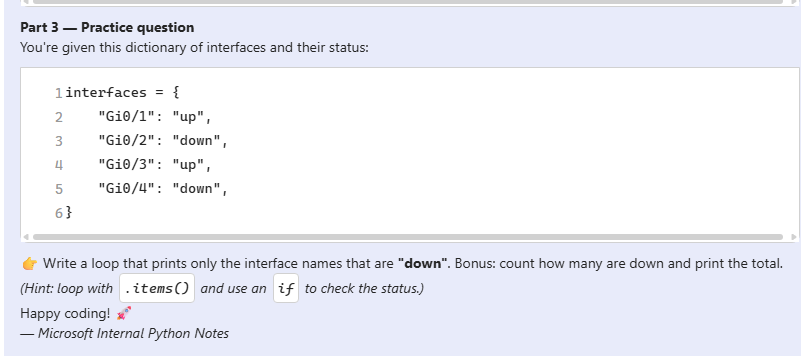

In [41]:
interfaces = {
    "Gi0/1": "up",
    "Gi0/2": "down",
    "Gi0/3": "up",
    "Gi0/4": "down",
}

🐍 Python for Network Engineers — Day 4: Tuples & Sets
Part 1 — The concept & why it matters
Today we add two more built-in collections to your toolkit: tuples and sets. They look similar to lists at first, but each solves a specific problem you'll hit constantly in network work.
Tuple = an ordered, unchangeable collection, written with parentheses: ("10.0.0.1", 22). Once created, you can't modify it. That "can't change it" property is a feature — it's perfect for grouped values that belong together and shouldn't be accidentally edited, like an (ip, port) pair, a (device, interface) combo, or geographic (lat, lon) coordinates. Bonus: because tuples are immutable, they can be used as dictionary keys (lists can't).
Set = an unordered collection of unique items, written with curly braces: {"10.0.0.1", "10.0.0.2"}. Sets automatically drop duplicates, and they make membership tests (x in my_set) and comparisons extremely fast. For a network engineer this is gold: dedupe a list of VLAN IDs, find which IPs appear in both two ACLs, or figure out which subnets are in your inventory but not yet monitored.
Part 2 — Example code snippets
Tuples — grouping values that belong together:
device = ("edge-rtr-01", "GigabitEthernet0/1", "up")
name, interface, status = device          # unpacking
print(f"{name} {interface} is {status}")
# edge-rtr-01 GigabitEthernet0/1 is up
# Tuples as dictionary keys — track status per (device, interface)
link_status = {
    ("sw1", "Gi0/1"): "up",
    ("sw1", "Gi0/2"): "down",
}
print(link_status[("sw1", "Gi0/2")])      # down
Sets — dedupe and compare:
vlans_seen = [10, 20, 10, 30, 20, 10]
unique_vlans = set(vlans_seen)
print(unique_vlans)                       # {10, 20, 30}
acl_a = {"10.0.0.1", "10.0.0.2", "10.0.0.5"}
acl_b = {"10.0.0.2", "10.0.0.5", "10.0.0.9"}
print(acl_a & acl_b)   # in BOTH:   {'10.0.0.2', '10.0.0.5'}
print(acl_a | acl_b)   # in EITHER:  all unique IPs across both
print(acl_a - acl_b)   # only in A:  {'10.0.0.1'}
Quick reference — set operators: & intersection (in both), | union (in either), - difference (in first but not second).
Part 3 — Practice question
You have two lists of subnets — one from your monitoring tool and one from your inventory:
monitored = ["10.1.0.0/24", "10.2.0.0/24", "10.3.0.0/24"]
inventory = ["10.2.0.0/24", "10.3.0.0/24", "10.4.0.0/24", "10.5.0.0/24"]
👉 Using sets, write code that prints the subnets that are in your inventory but are NOT being monitored (i.e., the coverage gap).
Hint: convert both lists to sets and use the difference operator -. Expected answer: {'10.4.0.0/24', '10.5.0.0/24'}.
Reply here with your solution and I'll check it! 🚀
— Microsoft Internal Python Notes

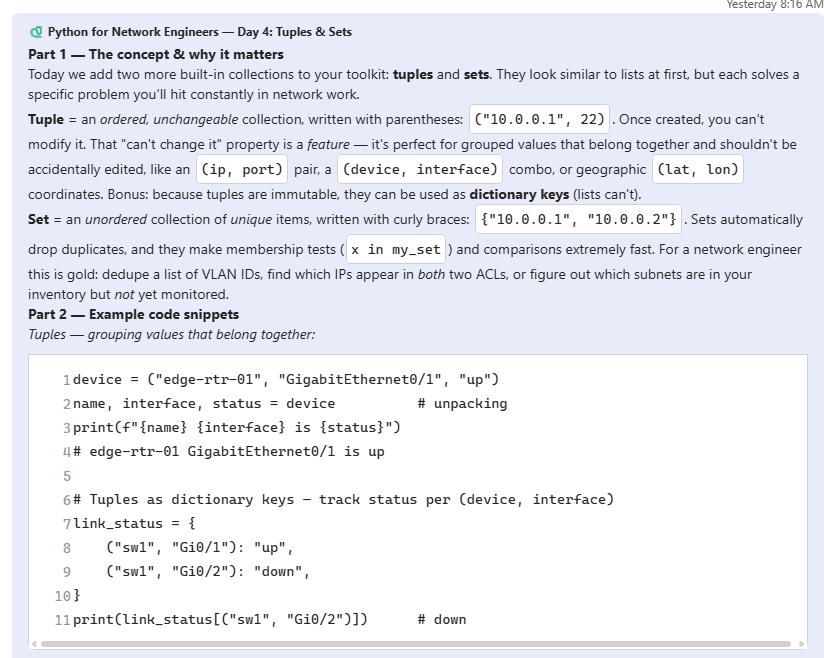

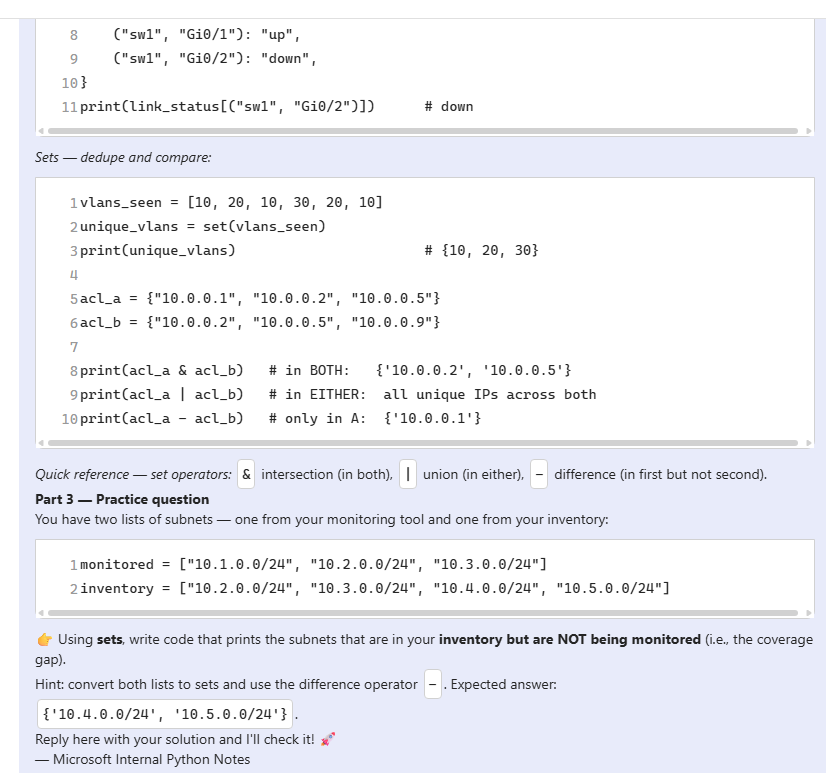




In [43]:
device = ("edge-rtr-01", "GigabitEthernet0/1", "up")
name, interface, status = device            #unpacking

print(f"{name} {interface} is {status}")
#edge-rtr-01 GigabitEthernet0/1 is up

link_status = {
    ("sw1", "Gi0/1"): "ip",
    ("sw1", "Gi0/2"): "down",
}

print(link_status[("sw1", "Gi0/2")])        #down


edge-rtr-01 GigabitEthernet0/1 is up
down


Sets — dedupe and compare:

In [46]:
vlan_seen = [10, 20, 10, 30, 20, 10]
unique_vlans = set(vlan_seen)
print(unique_vlans)                    #{10, 20, 30}


acl_a = {"10.0.0.1", "10.0.0.2", "10.0.0.5"}
acl_b = {"10.0.0.2", "10.0.0.5", "10.0.0.9"}

print(acl_a & acl_b)                                      # in BOTH:   {'10.0.0.2', '10.0.0.5'}
print(acl_a | acl_b)                                       # in EITHER:  all unique IPs across both
print(acl_a - acl_b)                                       # only in A:  {'10.0.0.1'}

{10, 20, 30}
{'10.0.0.5', '10.0.0.2'}
{'10.0.0.2', '10.0.0.1', '10.0.0.5', '10.0.0.9'}
{'10.0.0.1'}


Quick reference — set operators: & intersection (in both), | union (in either), - difference (in first but not second).

In [48]:
monitored = ["10.1.0.0/24", "10.2.0.0/24", "10.3.0.0/24"]
inventory = ["10.2.0.0/24", "10.3.0.0/24", "10.4.0.0/24", "10.5.0.0/24"]

coverage_gap1 = set(inventory) - set(monitored)

print(coverage_gap1)


{'10.5.0.0/24', '10.4.0.0/24'}


Here’s the clean set-based solution:

```python
monitored = ["10.1.0.0/24", "10.2.0.0/24", "10.3.0.0/24"]
inventory = ["10.2.0.0/24", "10.3.0.0/24", "10.4.0.0/24", "10.5.0.0/24"]

# Convert to sets and find difference
coverage_gap = set(inventory) - set(monitored)

print(coverage_gap)
```

✅ **Output:**

```python
{'10.4.0.0/24', '10.5.0.0/24'}
```

### 🔍 Explanation

* `set(inventory)` → removes duplicates (good for your data cleanup workflow)
* `set(monitored)` → monitored subnets
* `-` operator → gives items present in **inventory but not monitored**

👉 This is exactly how you'd quickly detect **monitoring gaps in a WAN lab or production environment**.

If you want, I can extend this to a script that also checks overlaps or validates subnet formats using `ipaddress` (useful for your automation pipelines).


In [49]:
import re
line = "2026-03-20T11:17:19 LON26 Ebra: %LINEPROTO-5-UPDOWN: Line protocol on Interface Ethernet5/27/1, changed state to down"
m = re.search(r"Interface (\S+), changed state to (\w+)", line)
if m:
    intf, state = m.group(1), m.group(2)
    print(intf, "->", state)     # Ethernet5/27/1 -> down

Ethernet5/27/1 -> down


In [50]:
import re
line = "2026-03-20T11:48:27.838+00:00 LON26-0100-0300-04RHE Macsec: %MKA-4-UNPROTECTED_TRAFFIC: Traffic is blocked"
pat = r"(?P<ts>\S+)\s+(?P<host>\S+)\s+(?P<proc>\w+): %(?P<code>[\w-]+):"
m = re.search(pat, line)
print(m.groupdict())
# {'ts': '2026-03-20T11:48:27.838+00:00', 'host': 'LON26-0100-0300-04RHE',
#  'proc': 'Macsec', 'code': 'MKA-4-UNPROTECTED_TRAFFIC'}

{'ts': '2026-03-20T11:48:27.838+00:00', 'host': 'LON26-0100-0300-04RHE', 'proc': 'Macsec', 'code': 'MKA-4-UNPROTECTED_TRAFFIC'}


🐍 Python for Network Engineers — Day 5: Functions (def, parameters, return)
Part 1 — The concept & why it matters
A function is a reusable block of code you define once and call many times. You give it a name, optionally hand it some parameters (inputs), and it can hand back a return value (output).
Why this matters for network engineering: you rarely do something to just one device. You write the logic once — "build a hostname config", "check if an IP is in a subnet", "ping a device and report status" — wrap it in a function, then call it in a loop across 500 routers. Functions kill copy-paste, make your scripts testable, and are the foundation of every automation tool (Netmiko, NAPALM, Nornir) you'll use later.
Three pieces to remember:
def — keyword that defines the function
parameters — the named inputs in the parentheses (and you can give them defaults)
return — sends a value back to the caller; without it, a function returns None
Part 2 — Example code snippets
# 1) A simple function: input -> output
def make_hostname(site, role, number):
    return f"{site}-{role}-{number:02d}"
print(make_hostname("sea", "core", 1))    # sea-core-01
print(make_hostname("nyc", "edge", 12))   # nyc-edge-12

# 2) A parameter with a DEFAULT value
def build_interface(intf, description, shutdown=False):
    lines = [f"interface {intf}", f" description {description}"]
    lines.append(" shutdown" if shutdown else " no shutdown")
    return "\n".join(lines)
print(build_interface("Gig0/1", "Uplink to spine"))
# interface Gig0/1
#  description Uplink to spine
#  no shutdown

# 3) Reuse a function inside a loop (the real payoff)
devices = ["10.0.0.1", "10.0.0.2", "10.0.0.3"]
def is_reachable(ip):
    # pretend we pinged it; return True/False
    return not ip.endswith(".2")   # fake: .2 is "down"
for ip in devices:
    status = "UP" if is_reachable(ip) else "DOWN"
    print(f"{ip} -> {status}")
# 10.0.0.1 -> UP
# 10.0.0.2 -> DOWN
# 10.0.0.3 -> UP

Notice in example 2 that shutdown=False is a default — callers can skip it. And every function above hands work back with return, so you can store, print, or pass the result onward.
Part 3 — Practice question
Write a function called subnet_summary that takes two parameters: network (a string like "192.168.10.0") and prefix (an int, defaulting to 24). It should return a string in CIDR form, e.g. "192.168.10.0/24". Then call it twice — once letting the prefix default, and once passing prefix=30 — and print both results.
Bonus: have the function also return a short label like "large" if the prefix is ≤ 24 and "small" otherwise. (Hint: a function can return a tuple — remember Day 4!) Drop your answer here and I'll review it tomorrow. 🚀
— Microsoft Internal Python Notes
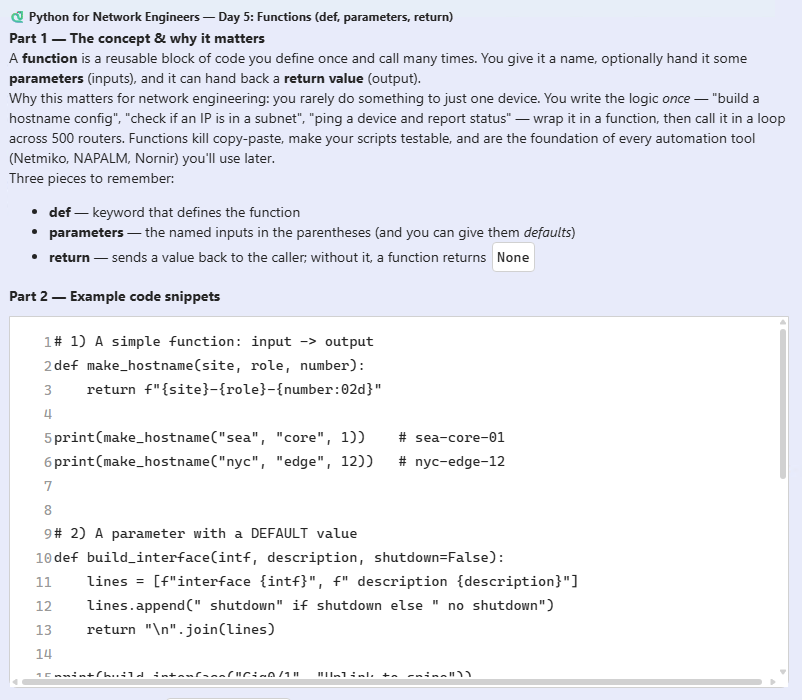

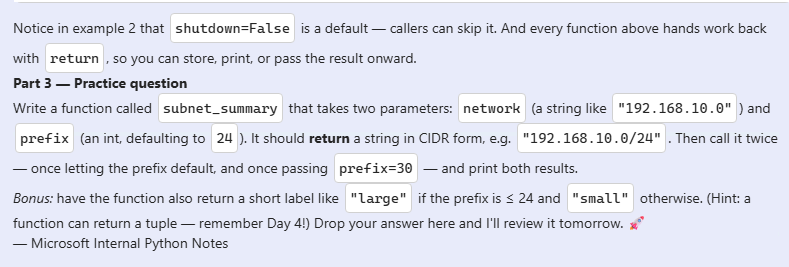



In [1]:
# 1) A simple function: input -> output

def make_hostname(site, role, number):
    return f"{site}-{role}-{number:02d}"

print(make_hostname("sea", "core", 1))    # sea-core-01
print(make_hostname("nyc", "edge", 12))     # nyc-edge-12

sea-core-01
nyc-edge-12


In [2]:
# 1) A simple function: input -> output

def make_hostname(site, role, number):
    return f"{site}-{role}-{number:02d}"

print(make_hostname("sea", "core", 1000000))    # sea-core-01
print(make_hostname("nyc", "edge", 12))     # nyc-edge-12

sea-core-1000000
nyc-edge-12


In [7]:
# 1) A simple function: input -> output

def make_hostname(site, role, number):
    return f"{site}-{role}-{number}"

print(make_hostname("sea", "core", 0.1))    # sea-core-01
print(make_hostname("nyc", "edge", 12))     # nyc-edge-12

sea-core-0.1
nyc-edge-12


In [6]:
# 1) A simple function: input -> output

def make_hostname(site, role, number):
    return f"{site}-{role}-{number:02d}"

print(make_hostname("sea", "core", 0.1))    # sea-core-01
print(make_hostname("nyc", "edge", 12))     # nyc-edge-12

ValueError: Unknown format code 'd' for object of type 'float'

In [5]:
# 1) A simple function: input -> output

def make_hostname(site, role, number):
    return f"{site}-{role}-{number:02f}"

print(make_hostname("sea", "core", 0.1))    # sea-core-01
print(make_hostname("nyc", "edge", 12))     # nyc-edge-12

sea-core-0.100000
nyc-edge-12.000000


In [3]:
# 1) A simple function: input -> output

def make_hostname(site, role, number):
    return f"{site}-{role}-{number:02d}"

print(make_hostname("sea", "core"))    # sea-core-01
print(make_hostname("nyc", "edge", 12))     # nyc-edge-12

TypeError: make_hostname() missing 1 required positional argument: 'number'

In [8]:
print(f"{1:02d}")    # 01
print(f"{9:02d}")    # 09
print(f"{12:02d}")   # 12
print(f"{100:02d}")  # 100  (no truncation)


01
09
12
100


In [9]:
print(f"{1:04d}")    # 01
print(f"{9:03d}")    # 09
print(f"{12:02d}")   # 12
print(f"{100:02d}")  # 100  (no truncation)


0001
009
12
100


In [10]:
# 2) A parameter with a DEFAULT value

def build_interface(intf, description, shutdown = False):
    lines = [f"interface {intf}", f"description {description}"]
    lines.append("shutdown" if shutdown else "no shutdown")
    return "\n".join(lines)

In [11]:
print(build_interface("Gig0/1", "Uplink to spine"))

interface Gig0/1
description Uplink to spine
no shutdown


In [12]:
print(build_interface("Gig0/1", "Uplink to spine", "shutdown"))

interface Gig0/1
description Uplink to spine
shutdown


In [13]:
# 3) Reuse a function inside a loop (the real payoff)

devices = ["10.0.0.1", "10.0.0.2", "10.0.0.3"]

def is_reachable(rip):
    #pretend we pinged it; return True/False
    return not ip.endswith(".2")   #fake .2 is "down"

for ip in devices:
    status = "UP" if is_reachable(ip) else "DOWN"
    print(f"{ip}  -> {status}")

10.0.0.1  -> UP
10.0.0.2  -> DOWN
10.0.0.3  -> UP


In [14]:
def make_hostname(site, role, number):
    return f"{site}-{role}-{number:02d}"


def build_interface(intf, description, vlan, ip, shutdown=False):
    lines = [
        f"interface {intf}",
        f"description {description}",
        f"switchport access vlan {vlan}",
        f"ip address {ip} 255.255.255.0"
    ]
    lines.append("shutdown" if shutdown else "no shutdown")
    return "\n".join(lines)


def generate_config(site, role, count):
    config = []

    # ✅ Hostname
    hostname = make_hostname(site, role, 1)
    config.append(f"hostname {hostname}")

    base_ip = "10.10.1."

    for i in range(1, count + 1):
        intf = f"GigabitEthernet0/{i}"
        desc = f"{role}-device-{i:02d}"
        vlan = 100 + (i % 10)   # rotating VLANs (100–109)
        ip = f"{base_ip}{i}"

        intf_config = build_interface(
            intf=intf,
            description=desc,
            vlan=vlan,
            ip=ip,
            shutdown=False
        )

        config.append(intf_config)

    return "\n!\n".join(config)


# ✅ Generate config for 10 interfaces (change to 100 if needed)
print(generate_config("sea", "leaf", 10))

hostname sea-leaf-01
!
interface GigabitEthernet0/1
description leaf-device-01
switchport access vlan 101
ip address 10.10.1.1 255.255.255.0
no shutdown
!
interface GigabitEthernet0/2
description leaf-device-02
switchport access vlan 102
ip address 10.10.1.2 255.255.255.0
no shutdown
!
interface GigabitEthernet0/3
description leaf-device-03
switchport access vlan 103
ip address 10.10.1.3 255.255.255.0
no shutdown
!
interface GigabitEthernet0/4
description leaf-device-04
switchport access vlan 104
ip address 10.10.1.4 255.255.255.0
no shutdown
!
interface GigabitEthernet0/5
description leaf-device-05
switchport access vlan 105
ip address 10.10.1.5 255.255.255.0
no shutdown
!
interface GigabitEthernet0/6
description leaf-device-06
switchport access vlan 106
ip address 10.10.1.6 255.255.255.0
no shutdown
!
interface GigabitEthernet0/7
description leaf-device-07
switchport access vlan 107
ip address 10.10.1.7 255.255.255.0
no shutdown
!
interface GigabitEthernet0/8
description leaf-device-

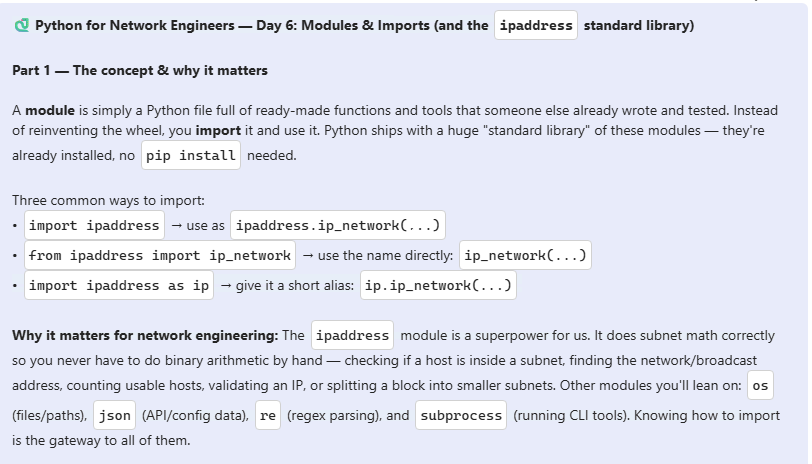

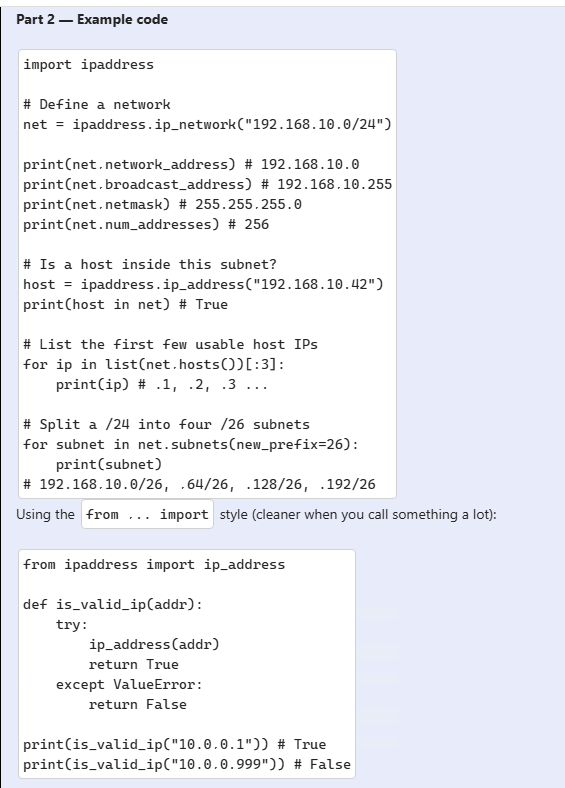

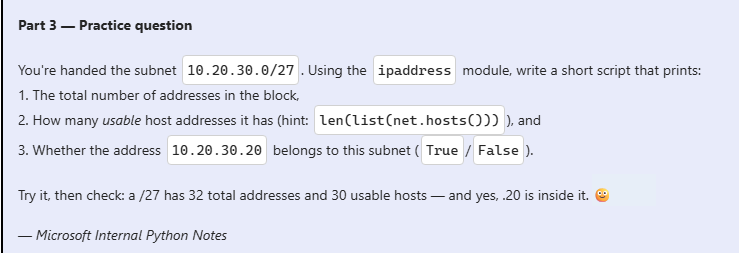


🐍 Python for Network Engineers — Day 6: Modules & Imports (and the ipaddress standard library)
Part 1 — The concept & why it matters
A module is simply a Python file full of ready-made functions and tools that someone else already wrote and tested. Instead of reinventing the wheel, you import it and use it. Python ships with a huge "standard library" of these modules — they're already installed, no pip install needed.
Three common ways to import:
• import ipaddress → use as ipaddress.ip_network(...)
• from ipaddress import ip_network → use the name directly: ip_network(...)
• import ipaddress as ip → give it a short alias: ip.ip_network(...)
Why it matters for network engineering: The ipaddress module is a superpower for us. It does subnet math correctly so you never have to do binary arithmetic by hand — checking if a host is inside a subnet, finding the network/broadcast address, counting usable hosts, validating an IP, or splitting a block into smaller subnets. Other modules you'll lean on: os (files/paths), json (API/config data), re (regex parsing), and subprocess (running CLI tools). Knowing how to import is the gateway to all of them.
Part 2 — Example code
import ipaddress
# Define a network
net = ipaddress.ip_network("192.168.10.0/24")
print(net.network_address) # 192.168.10.0
print(net.broadcast_address) # 192.168.10.255
print(net.netmask) # 255.255.255.0
print(net.num_addresses) # 256
# Is a host inside this subnet?
host = ipaddress.ip_address("192.168.10.42")
print(host in net) # True
# List the first few usable host IPs
for ip in list(net.hosts())[:3]:
    print(ip) # .1, .2, .3 ...
# Split a /24 into four /26 subnets
for subnet in net.subnets(new_prefix=26):
    print(subnet)
# 192.168.10.0/26, .64/26, .128/26, .192/26
Using the from ... import style (cleaner when you call something a lot):
from ipaddress import ip_address
def is_valid_ip(addr):
    try:
        ip_address(addr)
        return True
    except ValueError:
        return False
print(is_valid_ip("10.0.0.1")) # True
print(is_valid_ip("10.0.0.999")) # False

Part 3 — Practice question
You're handed the subnet 10.20.30.0/27. Using the ipaddress module, write a short script that prints:
1. The total number of addresses in the block,
2. How many usable host addresses it has (hint: len(list(net.hosts()))), and
3. Whether the address 10.20.30.20 belongs to this subnet (True/False).
Try it, then check: a /27 has 32 total addresses and 30 usable hosts — and yes, .20 is inside it. 🙂
— Microsoft Internal Python Notes


os (files/paths), json (API/config data), re (regex parsing), and subprocess (running CLI tools).

In [15]:
import os

In [16]:
import json

In [17]:
import re

In [18]:
import subprocess

In [19]:
import ipaddress

#define a network

net = ipaddress.ip_network("192.168.10.0/24")

print(net.network_address)   #192.168.10
print(net.broadcast_address)
print(net.netmask)
print(net.num_addresses)

192.168.10.0
192.168.10.255
255.255.255.0
256


In [20]:
# Is a host inside this subnet?

host = ipaddress.ip_address("192.168.10.42")
print(host in net)

True


In [22]:
host = ipaddress.ip_address("20.10.0.0")
print(host in net)

False


In [23]:
#list the first few usable host IP address:

for ip in list(net.hosts())[:3]:
    print(ip)

192.168.10.1
192.168.10.2
192.168.10.3


In [24]:
#list the first few usable host IP address:

for ip in list(net.hosts())[:10]:
    print(ip)

192.168.10.1
192.168.10.2
192.168.10.3
192.168.10.4
192.168.10.5
192.168.10.6
192.168.10.7
192.168.10.8
192.168.10.9
192.168.10.10


In [25]:
# Split a /24 into four /26 subnets

for subnet in net.subnets(new_prefix=26):
    print(subnet)

192.168.10.0/26
192.168.10.64/26
192.168.10.128/26
192.168.10.192/26


In [26]:
from ipaddress import ip_address

def is_valid_ip(addr):
    try:
        ip_address(addr)
        return True
    except ValueError:
        return False
    
print(is_valid_ip("10.0.0.1"))
print(is_valid_ip("10.0.0.999"))

True
False


In [27]:
print(is_valid_ip(1000))

True


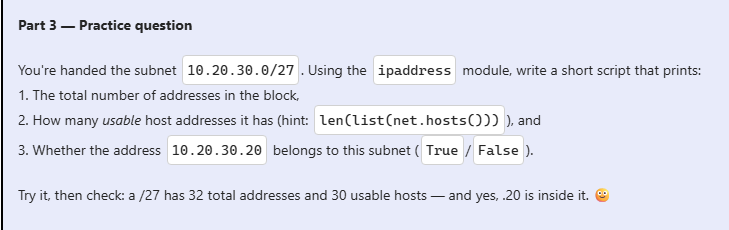

In [30]:
import ipaddress

#define a network

net1 = ipaddress.ip_network("10.20.30.0/27")

print(net1.network_address)   #192.168.10
print(net1.broadcast_address)
print(net1.netmask)
print(net1.num_addresses)

10.20.30.0
10.20.30.31
255.255.255.224
32


In [31]:
print(len(list(net1.hosts())))

30


In [33]:
host1 = ipaddress.ip_address("10.20.30.20")
print(host1 in net1)

True


In [34]:
host1 = ipaddress.ip_address("192.20.30.20")
print(host1 in net1)

False


🐍 Python for Network Engineers — Day 7: Exception Handling (try / except / finally)
Part 1 — The concept & why it matters
Up to now our scripts assumed everything goes right. In the real network world it doesn't: a device is unreachable, SSH times out, an API returns garbage, a config file is missing, or someone fat-fingers a subnet mask. By default, when Python hits one of these, it crashes — and if you're looping over 200 routers, one bad device kills the whole job.
Exception handling lets you catch errors, deal with them gracefully, and keep going. The pattern:
• try: — the risky code that might fail
• except SomeError: — what to do when that specific error happens
• else: — runs only if no error occurred (optional)
• finally: — runs no matter what, error or not — perfect for cleanup (close a connection, log the result)
Golden rule: catch specific exceptions, not a bare except:. Catching everything hides the bugs you actually need to see.
Part 2 — Example code
① The basics — catching a specific error
ip = "10.0.0.300"   # invalid!
try:
    octets = ip.split(".")
    last = int(octets[3])
    print(f"Last octet is {last}")
except IndexError:
    print(f"'{ip}' doesn't have 4 octets")
except ValueError:
    print(f"'{ip}' has a non-numeric octet")
② Looping over devices — one failure shouldn't stop the batch
devices = ["10.1.1.1", "10.1.1.2", "bad-host", "10.1.1.4"]
for host in devices:
    try:
        # pretend this connects via SSH
        if host == "bad-host":
            raise ConnectionError("unreachable")
        print(f"{host}: connected ✅")
    except ConnectionError as err:
        print(f"{host}: SKIPPED — {err} ❌")
    finally:
        print(f"  ...done checking {host}")
The finally block runs for every device — success or failure — so it's where you'd log results or close a session.
③ else + finally together
import ipaddress
def validate(addr):
    try:
        net = ipaddress.ip_network(addr, strict=False)
    except ValueError as e:
        print(f"Invalid: {addr} ({e})")
    else:
        print(f"Valid network: {net} — {net.num_addresses} addresses")
    finally:
        print("-" * 30)
validate("192.168.1.0/24")
validate("10.0.0.0/33")   # bad prefix length
Part 3 — Practice question
You're given a list of strings that are supposed to be port numbers:
ports = ["22", "443", "ssh", "8080", "-1"]
Write a loop that converts each to an integer and prints whether it's a valid TCP port (1–65535). Use try/except to catch the entries that aren't numbers (like "ssh") and print a friendly "not a number" message instead of crashing. Bonus: also flag "-1" as out of range.
Try it out and share your solution! 🚀
— Microsoft Internal Python Notes

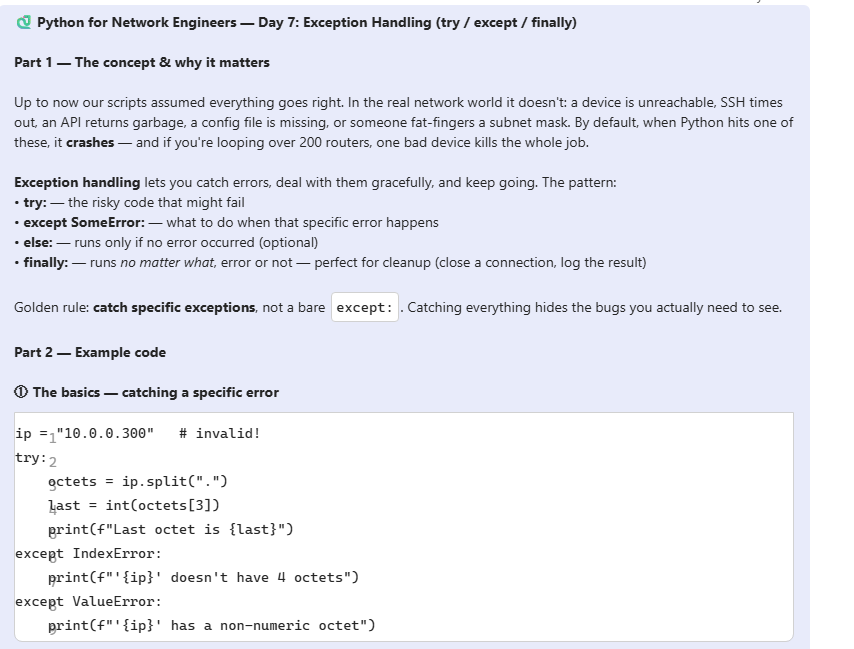

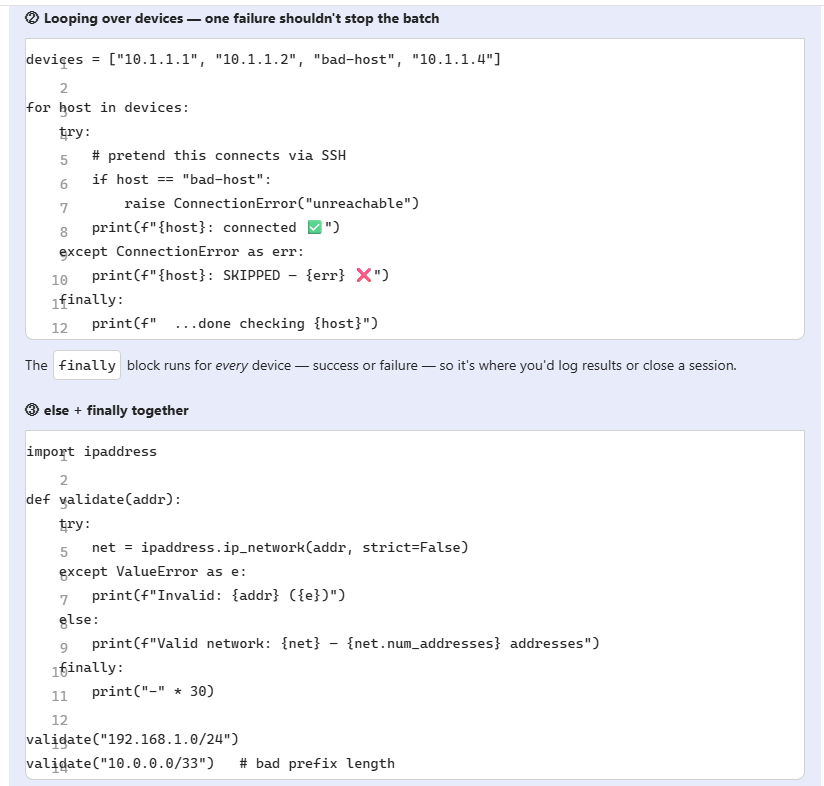

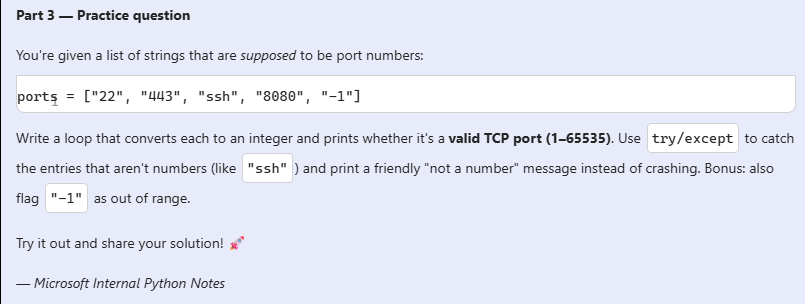


In [35]:
ip = "10.0.0.300" # invalid

try:
    octets = ip.split(".")
    last = int(octets[3])
    print(f"last octet is {last}")
except IndexError:
    print(f"'{ip}' does not have 4 octets")
except ValueError:
    print(f" '{ip}' has a non-numeric octet")

last octet is 300


In [36]:
ip = "10.0.0.30" # valid

try:
    octets = ip.split(".")
    last = int(octets[3])
    print(f"last octet is {last}")
except IndexError:
    print(f"'{ip}' does not have 4 octets")
except ValueError:
    print(f" '{ip}' has a non-numeric octet")

last octet is 30


In [37]:
ip = "10.0.0.40" # valid

try:
    octets = ip.split(".")
    last = int(octets[4])
    print(f"last octet is {last}")
except IndexError:
    print(f"'{ip}' does not have 4 octets")
except ValueError:
    print(f" '{ip}' has a non-numeric octet")

'10.0.0.40' does not have 4 octets


In [38]:
ip = "192.168.0.10" # valid

try:
    octets = ip.split(".")
    last = int(octets[3])
    print(f"last octet is {last}")
except IndexError:
    print(f"'{ip}' does not have 4 octets")
except ValueError:
    print(f" '{ip}' has a non-numeric octet")

last octet is 10


In [39]:
ip = "192.168.0.10" # valid

try:
    octets = ip.split(".")
    last = int(octets[2])
    print(f"last octet is {last}")
except IndexError:
    print(f"'{ip}' does not have 4 octets")
except ValueError:
    print(f" '{ip}' has a non-numeric octet")

last octet is 0


In [40]:
# Looping over devices — one failure shouldn't stop the batch

devices = ["10.1.1.1", "10.1.1.2", "bad-host", "10.1.1.4"]

for host in devices:
    try:
        #pretend this connects via SSH 
        if host == "bad-host":
            raise ConnectionError("unreachable")
        print(f" {host}: connected ✅")
    except ConnectionError as err:
        print(f"{host}: SKIPPED - {err} ❌")
    finally:
        print(f" .............done checking {host}")

 10.1.1.1: connected ✅
 .............done checking 10.1.1.1
 10.1.1.2: connected ✅
 .............done checking 10.1.1.2
bad-host: SKIPPED - unreachable ❌
 .............done checking bad-host
 10.1.1.4: connected ✅
 .............done checking 10.1.1.4


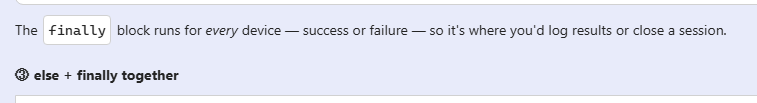

In [41]:
import ipaddress

def validate(addr):
    try:
        net = ipaddress.ip_network(addr, strict=False)
    except ValueError as e:
        print(f"Invalid : {addr}  ({e})")
    else:
        print(f"Valid network: {net} - {net.num_addresses} addresses ")
    finally:
        print("-" * 30)

validate("192.168.1.0/24")
validate("10.0.0.0/33")

Valid network: 192.168.1.0/24 - 256 addresses 
------------------------------
Invalid : 10.0.0.0/33  ('10.0.0.0/33' does not appear to be an IPv4 or IPv6 network)
------------------------------


In [42]:
validate("290.300.8.78900")

Invalid : 290.300.8.78900  ('290.300.8.78900' does not appear to be an IPv4 or IPv6 network)
------------------------------


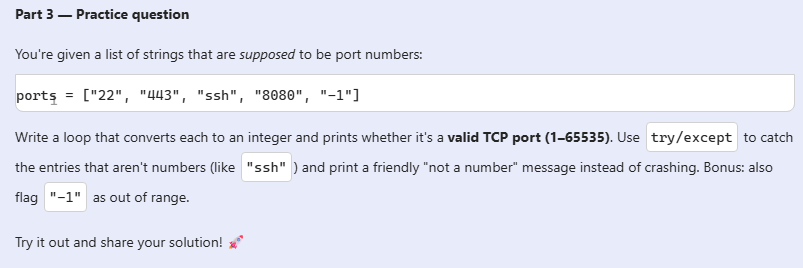

In [43]:
ports = ["22", "443", "ssh", "8080", "-1"]

try:
    for port in ports:
        if port in range(1,65535):
            print("it is an number with valid range")
        else:
            print("it is not an valid number")
except:
    print("There is something wrong")

it is not an valid number
it is not an valid number
it is not an valid number
it is not an valid number
it is not an valid number


In [1]:
ports = ["22", "443", "ssh", "8080", "-1"]

for port in ports:
    try:
        p =int(port)

        if 1 <= p <= 65535:
            print(f"port --> valid TCP port")
        else:
            print(f"{port} --> out of range")
    except ValueError:
        print(f"{port} --> not a number")

port --> valid TCP port
port --> valid TCP port
ssh --> not a number
port --> valid TCP port
-1 --> out of range


In [2]:
lines = [
    "Gi0/1 status up speed 1000",
    "Gi0/2 status down speed 0",
    "Te1/1 status up speed 10000",
    "Lo0 status up speed unknown"
]

In [3]:
lines = [
    "Gi0/1 status up speed 1000",
    "Gi0/2 status down speed 0",
    "Te1/1 status up speed 10000",
    "Lo0 status up speed unknown"
]

for line in lines:
    parts = line.split()
    interface = parts[0]
    speed = parts[-1]

    try:
        sp = int(speed)

        if sp >= 1000:
            print(f"{interface} → high speed")
        else:
            print(f"{interface} → low speed")

    except ValueError:
        print(f"{interface} → not a number")

Gi0/1 → high speed
Gi0/2 → low speed
Te1/1 → high speed
Lo0 → not a number
